# Phase 1: Starling → AFRC Filter → FoldMason Pipeline

End-to-end IDP ensemble generation and conformer selection in one notebook.

**Requires**: GPU runtime (`Runtime > Change runtime type > T4 GPU`)

## What this notebook does
1. Runs **Starling** on a trimmed IDP sequence → conformer ensemble
2. Applies **AFRC** Rg filter (sequence-specific random coil reference) + deviation maps
3. Runs **FoldMason** on filtered frames → structural MSA + 3Di tokens + lDDT
4. Ranks conformers by lDDT + epitope structural content → `_binder_ready/`
5. Downloads everything as a single zip

**Output**: top 3–5 conformers ready for RFDiffusion / BindCraft / Forge

## 0. Check GPU

In [9]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU — switch to GPU runtime')

Sat Mar 14 23:18:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies

In [10]:
!pip install -q idptools-starling MDAnalysis afrc

In [11]:
import subprocess
import importlib
import os, sys, glob, shutil, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
from afrc import AnalyticalFRC

# Download and setup FoldMason if not already present
if not os.path.exists('./foldmason/bin/foldmason'):
    print('FoldMason not found. Downloading...')
    # Clean up any previous partial installations
    if os.path.exists('./foldmason'):
        shutil.rmtree('./foldmason')
    # Use the AVX2 build from mmseqs.com
    !wget -q https://mmseqs.com/foldmason/foldmason-linux-avx2.tar.gz
    !tar -xzf foldmason-linux-avx2.tar.gz
    !chmod +x foldmason/bin/foldmason
    if not os.path.exists('./foldmason/bin/foldmason'):
        raise FileNotFoundError("FoldMason binary not found after download and extraction. Please check the URL or your environment.")
    print('FoldMason downloaded and extracted.')
else:
    print('FoldMason already exists.')

# FoldMason binary check
r = subprocess.run(['./foldmason/bin/foldmason', 'version'], capture_output=True, text=True)
print('FoldMason  :', r.stdout.strip()[:60] if r.returncode == 0 else 'MISSING')
print('MDAnalysis :', mda.__version__)
print('AFRC       : OK')
print('numpy      :', np.__version__)

# Starling — imported lazily (only needed when running the Starling cell)
r2 = subprocess.run(['starling', '--help'], capture_output=True, text=True)
print('Starling   :', 'OK' if r2.returncode == 0 else 'MISSING — check pip install above')

FoldMason not found. Downloading...
FoldMason downloaded and extracted.
FoldMason  : 4bd8b8d8c20d439b52ff8a3fccc50a3aba2be286
MDAnalysis : 2.10.0
AFRC       : OK
numpy      : 2.0.2
Starling   : OK


In [12]:
import subprocess
r = subprocess.run(['./foldmason/bin/foldmason', 'version'], capture_output=True, text=True)
print('FoldMason:', r.stdout.strip()[:60])
from afrc import AnalyticalFRC
print('AFRC: OK')
print('Starling check:')
!starling --help 2>&1 | head -2

FoldMason: 4bd8b8d8c20d439b52ff8a3fccc50a3aba2be286
AFRC: OK
Starling check:
usage: starling [-h] [-c CONFORMATIONS] [-d DEVICE] [-s STEPS] [-b BATCH_SIZE]
                [-o OUTPUT_DIRECTORY] [--outname OUTNAME] [-r] [-v]


## 2. Configuration

Edit this cell only. Everything else runs automatically.

In [13]:
# ── EDIT THESE ──────────────────────────────────────────────────────────────

PROTEIN_NAME  = 'tau_k18'
N_CONFORMERS  = 400          # 100 = exploration | 400 = production

# Trimmed IDP sequence — disordered region only (no structured domains)
# Tau K18 repeat domain (MTBR R1–R4, residues 244–368, 2N4R numbering)
SEQUENCE = (
    'KVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGG'
    'QVEVKSEKLDFKDRVQSKIGSLDNITHVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPV'
    'VSGDTSPRHLSNVSSTGSIDMVDSPQLATLADEVSASLAKQGL'
)

# Epitope residue ranges (1-indexed positions in SEQUENCE)
# Format: (start, end, label, weight)
#
# Weights reflect scientific priority from Sugiyama et al. 2025:
#   PHF6* / PHF6 = primary aggregation drivers (highest Writhe signal)
#   jR2R3        = counterstrand anchor that holds PHF6 in place;
#                  weighted 0.5 so its 19 residues don't dominate scoring
#
# K18 1-indexed positions (2N4R residue = K18 pos + 243):
#   PHF6*  : 2N4R 275–280  → K18  2–7
#   PHF6   : 2N4R 306–311  → K18 33–38  (note: seq shows VQIVYK at 33–38 ✓)
#   jR2R3  : 2N4R 295–313  → K18 52–70  (19-aa counterstrand, Sugiyama 2025)
EPITOPE_RANGES = [
    (2,  7,  'PHF6* VQIINK', 1.0),
    (33, 38, 'PHF6 VQIVYK',  1.0),
    (52, 70, 'jR2R3',         0.5),
]

# FoldMason conformer selection
TOP_N          = 5    # conformers to keep for binder design
LDDT_WEIGHT    = 0.6
EPITOPE_WEIGHT = 0.4

# ─────────────────────────────────────────────────────────────────────────────

# Flat list of 0-indexed positions for AFRC deviation plot shading
epitope_positions = []
for start, end, label, *_ in EPITOPE_RANGES:
    epitope_positions.extend(range(start - 1, end))

print(f'Protein    : {PROTEIN_NAME}')
print(f'Length     : {len(SEQUENCE)} aa')
print(f'Conformers : {N_CONFORMERS}')
print(f'Top N      : {TOP_N}')
print()
print('Epitope verification:')
for start, end, label, weight in EPITOPE_RANGES:
    print(f'  {label:20s} pos {start:3d}–{end:3d}  weight={weight}  seq={SEQUENCE[start-1:end]}')

Protein    : tau_k18
Length     : 168 aa
Conformers : 400
Top N      : 5

Epitope verification:
  PHF6* VQIINK         pos   2–  7  weight=1.0  seq=VQIINK
  PHF6 VQIVYK          pos  33– 38  weight=1.0  seq=VQIVYK
  jR2R3                pos  52– 70  weight=0.5  seq=LGNIHHKPGGGQVEVKSEK


## 3. Run Starling

Generates a conformational ensemble for the IDP sequence.

Outputs: `{PROTEIN_NAME}_STARLING.pdb` (topology) + `_STARLING.xtc` (trajectory)

In [14]:
import os
os.makedirs('output', exist_ok=True)
%cd output

/content/output/output


In [15]:
cmd = f'starling {SEQUENCE} --outname {PROTEIN_NAME} -c {N_CONFORMERS} -r'
print(f'Running: {cmd[:80]}...\n')
!{cmd}

Running: starling KVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKL...

Using DDIM sampler
Progress through sequences:   0% 0/1 [00:00<?, ?it/s]
DDIM steps (batch 1 of 4):   0% 0/31 [00:00<?, ?it/s]
DDIM steps (batch 1 of 4):   3% 1/31 [00:00<00:14,  2.05it/s]
DDIM steps (batch 1 of 4):   6% 2/31 [00:00<00:09,  2.92it/s]
DDIM steps (batch 1 of 4):  10% 3/31 [00:00<00:08,  3.33it/s]
DDIM steps (batch 1 of 4):  13% 4/31 [00:01<00:07,  3.58it/s]
DDIM steps (batch 1 of 4):  16% 5/31 [00:01<00:06,  3.72it/s]
DDIM steps (batch 1 of 4):  19% 6/31 [00:01<00:06,  3.82it/s]
DDIM steps (batch 1 of 4):  23% 7/31 [00:01<00:06,  3.87it/s]
DDIM steps (batch 1 of 4):  26% 8/31 [00:02<00:05,  3.91it/s]
DDIM steps (batch 1 of 4):  29% 9/31 [00:02<00:05,  3.95it/s]
DDIM steps (batch 1 of 4):  32% 10/31 [00:02<00:05,  3.97it/s]
DDIM steps (batch 1 of 4):  35% 11/31 [00:02<00:05,  3.98it/s]
DDIM steps (batch 1 of 4):  39% 12/31 [00:03<00:04,  3.99it/s]
DDIM steps (batch 1 of 4):  42% 

In [16]:
pdb_file = f'{PROTEIN_NAME}_STARLING.pdb'
xtc_file = f'{PROTEIN_NAME}_STARLING.xtc'
assert os.path.exists(pdb_file), f'Missing: {pdb_file}'
assert os.path.exists(xtc_file), f'Missing: {xtc_file}'
print(f'PDB : {pdb_file}  ({os.path.getsize(pdb_file)//1024} KB)')
print(f'XTC : {xtc_file}  ({os.path.getsize(xtc_file)//1024} KB)')

PDB : tau_k18_STARLING.pdb  (13 KB)
XTC : tau_k18_STARLING.xtc  (313 KB)


## 4. Extract PDB frames

In [17]:
import MDAnalysis as mda
import numpy as np

def extract_frames(topology, trajectory, output_dir, n_frames=100):
    os.makedirs(output_dir, exist_ok=True)
    u = mda.Universe(topology, trajectory)
    total   = len(u.trajectory)
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    saved   = []
    for i, ts_idx in enumerate(indices):
        u.trajectory[ts_idx]
        out = os.path.join(output_dir, f'frame_{i+1:04d}.pdb')
        u.atoms.write(out)
        saved.append(out)
    print(f'Extracted {len(saved)} frames → {output_dir}/')
    return saved

frames_dir = f'{PROTEIN_NAME}_frames'
frames     = extract_frames(pdb_file, xtc_file, frames_dir, n_frames=N_CONFORMERS)
print(f'First frame: {frames[0]}')

/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:885: UserWarning: Unit cell dimensions not found. CRYST1 record set to unitary values.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:1282: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn(


Extracted 400 frames → tau_k18_frames/
First frame: tau_k18_frames/frame_0001.pdb


import matplotlib.pyplot as plt
import glob as _glob

# ── AFRC reference state ─────────────────────────────────────────────────────
afrc    = AnalyticalFRC(SEQUENCE)
rg_afrc = afrc.get_mean_radius_of_gyration()
re_afrc = afrc.get_mean_end_to_end_distance()

print(f'AFRC reference ({len(SEQUENCE)} aa):  Rg={rg_afrc:.1f} Å   Re={re_afrc:.1f} Å')

# Build NxN mean distance map from pairwise distributions
# get_interresidue_distance_distribution(i, j) → [bins, p_r]
# mean distance = expected value of distribution
print('Building AFRC distance map (analytical, ~5s)...')
n = len(SEQUENCE)
afrc_dist = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        bins, p_r = afrc.get_interresidue_distance_distribution(i, j)
        mean_d = float(np.sum(np.array(bins) * np.array(p_r)))
        afrc_dist[i, j] = mean_d
        afrc_dist[j, i] = mean_d
print('Distance map done.')

# ── Load Rg from extracted PDB files ─────────────────────────────────────────
frame_files   = sorted(_glob.glob(os.path.join(frames_dir, 'frame_*.pdb')))
n_frames_traj = len(frame_files)
print(f'Extracted frames: {n_frames_traj}')

rg_all    = []
ca_arrays = []
n_residues = None

for fn in frame_files:
    u_f  = mda.Universe(fn)
    ca_f = u_f.select_atoms('name CA')
    if n_residues is None:
        n_residues = len(ca_f)
    rg_all.append(ca_f.radius_of_gyration())
    ca_arrays.append(ca_f.positions.copy())

rg_all = np.array(rg_all)

# ── Rg filter (±2σ) ──────────────────────────────────────────────────────────
rg_mean, rg_std = rg_all.mean(), rg_all.std()
rg_lo, rg_hi    = rg_mean - 2 * rg_std, rg_mean + 2 * rg_std
keep_idx        = np.where((rg_all >= rg_lo) & (rg_all <= rg_hi))[0]

print(f'Rg  mean={rg_mean:.1f}  std={rg_std:.1f} Å')
print(f'AFRC ref : {rg_afrc:.1f} Å  |  deviation: {rg_mean - rg_afrc:+.1f} Å ({100*(rg_mean-rg_afrc)/rg_afrc:+.1f}%)')
print(f'Passing  : {len(keep_idx)}/{n_frames_traj} ({100*len(keep_idx)/n_frames_traj:.0f}%)')

# ── Positions of passing frames ───────────────────────────────────────────────
positions = np.array([ca_arrays[i] for i in keep_idx])

# ── Observed mean Cα distance map ────────────────────────────────────────────
obs_dist = np.zeros((n_residues, n_residues))
for k in range(len(positions)):
    diff      = positions[k][:, None, :] - positions[k][None, :, :]
    obs_dist += np.linalg.norm(diff, axis=-1)
obs_dist /= len(positions)

# ── Fractional deviation from AFRC ───────────────────────────────────────────
ad = afrc_dist[:n_residues, :n_residues]
with np.errstate(invalid='ignore', divide='ignore'):
    deviation = np.where(ad > 0, (obs_dist - ad) / ad, 0.0)
np.fill_diagonal(deviation, 0)
marginal_dev = np.abs(deviation).mean(axis=1)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
ax.hist(rg_all, bins=30, color='steelblue', edgecolor='white', alpha=0.8, label='All')
ax.hist(rg_all[keep_idx], bins=30, color='seagreen', edgecolor='white', alpha=0.6, label='Passing')
ax.axvline(rg_mean, color='steelblue', ls='--', lw=1.5, label=f'Observed={rg_mean:.1f} Å')
ax.axvline(rg_afrc, color='tomato',    ls='-',  lw=2,   label=f'AFRC={rg_afrc:.1f} Å')
ax.axvline(rg_lo,   color='gray',      ls=':',  lw=1)
ax.axvline(rg_hi,   color='gray',      ls=':',  lw=1, label='±2σ')
ax.set_xlabel('Rg (Å)'); ax.set_ylabel('Count')
ax.set_title('Rg distribution vs AFRC reference'); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.plot(range(1, n_residues + 1), marginal_dev, color='darkorange', lw=1.5)
ax.axhline(marginal_dev.mean(), color='gray', ls='--', lw=1, label=f'mean={marginal_dev.mean():.3f}')
epi_colors = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}
for start, end, label, *_ in EPITOPE_RANGES:
    ax.axvspan(start, end, alpha=0.2, color=epi_colors.get(label, 'gray'), label=label)
ax.set_xlabel('Residue (1-indexed)'); ax.set_ylabel('Mean |deviation| from AFRC R(i,j)')
ax.set_title('Per-residue deviation from random coil\nPeaks at termini = trim candidates')
ax.legend(fontsize=7)

ax = axes[1, 0]
im = ax.imshow(obs_dist, cmap='viridis_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Cα–Cα distance (Å)')
ax.set_xlabel('Residue j'); ax.set_ylabel('Residue i')
ax.set_title('Observed mean Cα–Cα distance map')

ax = axes[1, 1]
vmax = max(0.3, float(np.abs(deviation).max()) * 0.8)
im2  = ax.imshow(deviation, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax, label='(obs − AFRC) / AFRC')
ax.set_xlabel('Residue j'); ax.set_ylabel('Residue i')
ax.set_title('Fractional deviation from AFRC R(i,j)\nRed=extended  Blue=compact vs random coil')

plt.suptitle(f'{PROTEIN_NAME} — Ensemble vs AFRC reference state', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROTEIN_NAME}_ensemble_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ensemble_analysis.png')
print('\n→ Plot B: peaks at N/C termini = trim those residues in next Starling run')
print('→ Plot D: blue off-diagonal = transient contacts (aggregation-prone regions)')

AFRC reference (168 aa):  Rg=32.3 Å   Re=75.4 Å
Extracted frames : 400


/usr/local/lib/python3.12/dist-packages/MDAnalysis/coordinates/PDB.py:479: UserWarning: 1 A^3 CRYST1 record, this is usually a placeholder. Unit cell dimensions will be set to None.
  warnings.warn(


Rg  mean=41.8  std=7.9 Å
AFRC ref : 32.3 Å  |  deviation: +9.5 Å (+29.3%)
Passing  : 385/400 (96%)


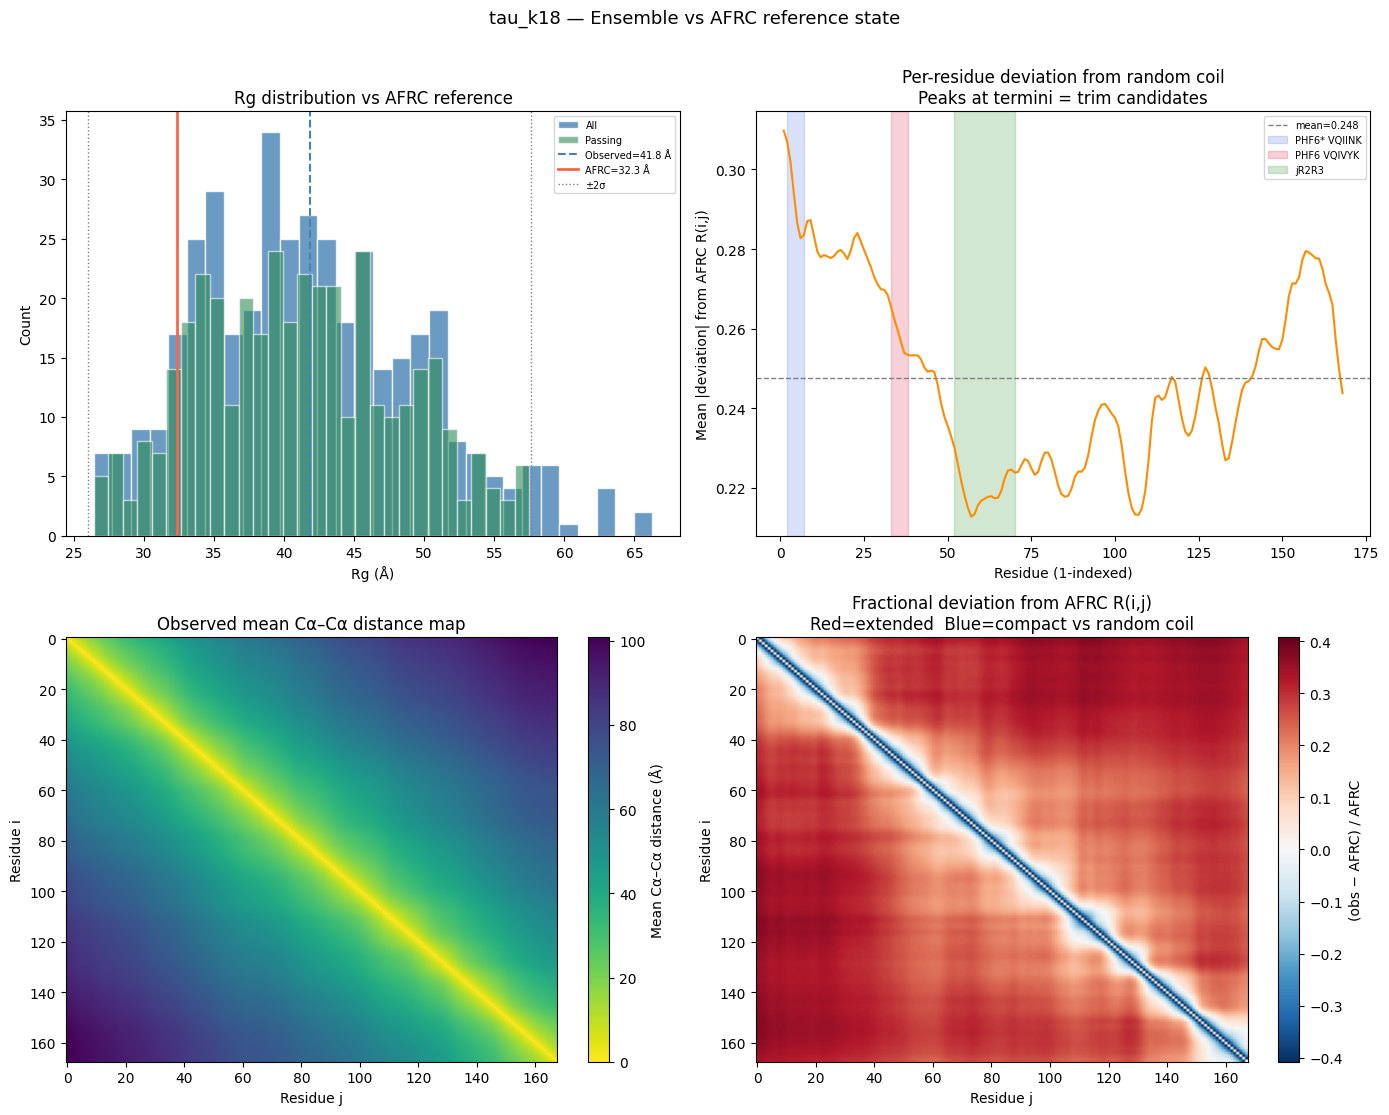

Saved ensemble_analysis.png

→ Plot B: peaks at N/C termini = trim those residues in next Starling run
→ Plot D: blue off-diagonal = transient contacts (aggregation-prone regions)


In [18]:
import matplotlib.pyplot as plt
import glob as _glob
from afrc import AnalyticalFRC

# ── AFRC reference state ─────────────────────────────────────────────────────
afrc       = AnalyticalFRC(SEQUENCE)
rg_afrc    = afrc.get_mean_radius_of_gyration()
re_afrc    = afrc.get_mean_end_to_end_distance()
afrc_dist  = afrc.get_distance_map(symmetric_map=True)   # (N×N)

print(f'AFRC reference ({len(SEQUENCE)} aa):  Rg={rg_afrc:.1f} Å   Re={re_afrc:.1f} Å')

# ── Load Rg from extracted PDB files (robust — no raw trajectory indexing) ───
# Using the PDB files avoids a mismatch: the raw Starling trajectory may have
# more frames than N_CONFORMERS; keep_idx must index the extracted frame list.
frame_files    = sorted(_glob.glob(os.path.join(frames_dir, 'frame_*.pdb')))
n_frames_traj  = len(frame_files)
print(f'Extracted frames : {n_frames_traj}')

rg_all     = []
ca_arrays  = []
n_residues = None

for fn in frame_files:
    u_f  = mda.Universe(fn)
    ca_f = u_f.select_atoms('name CA')
    if n_residues is None:
        n_residues = len(ca_f)
    rg_all.append(ca_f.radius_of_gyration())
    ca_arrays.append(ca_f.positions.copy())

rg_all = np.array(rg_all)

# ── Rg filter (±2σ) ──────────────────────────────────────────────────────────
rg_mean, rg_std = rg_all.mean(), rg_all.std()
rg_lo, rg_hi    = rg_mean - 2*rg_std, rg_mean + 2*rg_std
keep_idx        = np.where((rg_all >= rg_lo) & (rg_all <= rg_hi))[0]
# keep_idx now indexes frame_files (0..N_CONFORMERS-1), consistent with cell 17

print(f'Rg  mean={rg_mean:.1f}  std={rg_std:.1f} Å')
print(f'AFRC ref : {rg_afrc:.1f} Å  |  deviation: {rg_mean-rg_afrc:+.1f} Å ({100*(rg_mean-rg_afrc)/rg_afrc:+.1f}%)')
print(f'Passing  : {len(keep_idx)}/{n_frames_traj} ({100*len(keep_idx)/n_frames_traj:.0f}%)')

# ── Positions of passing frames ───────────────────────────────────────────────
positions = np.array([ca_arrays[i] for i in keep_idx])

# ── Observed mean Cα distance map ────────────────────────────────────────────
obs_dist = np.zeros((n_residues, n_residues))
for k in range(len(positions)):
    diff      = positions[k][:, None, :] - positions[k][None, :, :]
    obs_dist += np.linalg.norm(diff, axis=-1)
obs_dist /= len(positions)

# ── Fractional deviation from AFRC ────────────────────────────────────────────
ad = afrc_dist[:n_residues, :n_residues]
with np.errstate(invalid='ignore', divide='ignore'):
    deviation = np.where(ad > 0, (obs_dist - ad) / ad, 0.0)
np.fill_diagonal(deviation, 0)
marginal_dev = np.abs(deviation).mean(axis=1)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

ax = axes[0, 0]
ax.hist(rg_all, bins=30, color='steelblue', edgecolor='white', alpha=0.8, label='All')
ax.hist(rg_all[keep_idx], bins=30, color='seagreen', edgecolor='white', alpha=0.6, label='Passing')
ax.axvline(rg_mean, color='steelblue', ls='--', lw=1.5, label=f'Observed={rg_mean:.1f} Å')
ax.axvline(rg_afrc, color='tomato',    ls='-',  lw=2,   label=f'AFRC={rg_afrc:.1f} Å')
ax.axvline(rg_lo,   color='gray',      ls=':',  lw=1)
ax.axvline(rg_hi,   color='gray',      ls=':',  lw=1, label='±2σ')
ax.set_xlabel('Rg (Å)'); ax.set_ylabel('Count')
ax.set_title('Rg distribution vs AFRC reference'); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.plot(range(1, n_residues+1), marginal_dev, color='darkorange', lw=1.5)
ax.axhline(marginal_dev.mean(), color='gray', ls='--', lw=1, label=f'mean={marginal_dev.mean():.3f}')
epi_colors = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}
for start, end, label, *_ in EPITOPE_RANGES:
    color = epi_colors.get(label, 'gray')
    ax.axvspan(start, end, alpha=0.2, color=color, label=label)
ax.set_xlabel('Residue (1-indexed)'); ax.set_ylabel('Mean |deviation| from AFRC R(i,j)')
ax.set_title('Per-residue deviation from random coil\nPeaks at termini = trim candidates')
ax.legend(fontsize=7)

ax = axes[1, 0]
im = ax.imshow(obs_dist, cmap='viridis_r', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean Cα–Cα distance (Å)')
ax.set_xlabel('Residue j'); ax.set_ylabel('Residue i')
ax.set_title('Observed mean Cα–Cα distance map')

ax = axes[1, 1]
vmax = max(0.3, float(np.abs(deviation).max()) * 0.8)
im2  = ax.imshow(deviation, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im2, ax=ax, label='(obs − AFRC) / AFRC')
ax.set_xlabel('Residue j'); ax.set_ylabel('Residue i')
ax.set_title('Fractional deviation from AFRC R(i,j)\nRed=extended  Blue=compact vs random coil')

plt.suptitle(f'{PROTEIN_NAME} — Ensemble vs AFRC reference state', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROTEIN_NAME}_ensemble_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved ensemble_analysis.png')
print('\n→ Plot B: peaks at N/C termini = trim those residues in next Starling run')
print('→ Plot D: blue off-diagonal = transient contacts (aggregation-prone regions)')

## 6. Write filtered frames

In [19]:
import shutil

filtered_dir = f'{PROTEIN_NAME}_frames_filtered'
os.makedirs(filtered_dir, exist_ok=True)

for rank, frame_idx in enumerate(keep_idx):
    src = frame_files[frame_idx]   # frame_files defined in cell 15 — correct index
    dst = os.path.join(filtered_dir, f'filtered_{rank+1:04d}.pdb')
    shutil.copy2(src, dst)

n_filtered = len(os.listdir(filtered_dir))
print(f'Filtered frames : {n_filtered} → {filtered_dir}/')
print(f'Dropped         : {n_frames_traj - len(keep_idx)} outlier conformers '
      f'({100*(n_frames_traj-len(keep_idx))/n_frames_traj:.1f}%)')

Filtered frames : 385 → tau_k18_frames_filtered/
Dropped         : 15 outlier conformers (3.8%)


fm_bin     = '../foldmason/bin/foldmason'   # relative to output/
fm_db      = f'{PROTEIN_NAME}_foldmason_db'
fm_db_tmp  = f'{PROTEIN_NAME}_foldmason_db_tmp'
fm_msa_out = f'{PROTEIN_NAME}_foldmason_msa'
fm_msa_tmp = f'{PROTEIN_NAME}_foldmason_msa_tmp'
fm_json    = f'{PROTEIN_NAME}_foldmason.json'

os.makedirs(fm_msa_tmp, exist_ok=True)

# Step 1: create structure database from filtered PDB frames
print('Step 1/3: createdb...')
r1 = subprocess.run([
    fm_bin, 'createdb', filtered_dir, fm_db, fm_db_tmp
], capture_output=True, text=True)
print('  OK' if r1.returncode == 0 else f'  ERROR: {r1.stderr[-300:]}')

# Step 2: run structural MSA
print('Step 2/3: easy-msa...')
r2 = subprocess.run([
    fm_bin, 'easy-msa',
    filtered_dir, fm_msa_out, fm_msa_tmp,
    '--report-mode', '2',
    '--threads', '2',
], capture_output=True, text=True)
print('  OK' if r2.returncode == 0 else f'  ERROR: {r2.stderr[-300:]}')

# Step 3: generate lDDT JSON (needed for conformer ranking)
print('Step 3/3: msa2lddtjson...')
msa_fa = f'{fm_msa_out}_aa.fa'
r3 = subprocess.run([
    fm_bin, 'msa2lddtjson',
    fm_db, msa_fa, fm_json
], capture_output=True, text=True)
print('  OK' if r3.returncode == 0 else f'  ERROR: {r3.stderr[-300:]}')

print(f'\nFoldMason done.')
print(f'  MSA FASTA : {msa_fa}')
print(f'  JSON      : {fm_json}  ({os.path.getsize(fm_json)//1024 if os.path.exists(fm_json) else "MISSING"} KB)')

In [33]:
fm_bin_relative = '../foldmason/bin/foldmason'
fm_bin_full_path = os.path.abspath(fm_bin_relative) # Ensure absolute path to executable
fm_db_name = f'{PROTEIN_NAME}_foldmason_db'
fm_db_tmp_name = f'{PROTEIN_NAME}_foldmason_db_tmp'
fm_msa_out_name = f'{PROTEIN_NAME}_foldmason_msa'
fm_msa_tmp_name = f'{PROTEIN_NAME}_foldmason_msa_tmp'
fm_json_name = f'{PROTEIN_NAME}_foldmason_msa.json'

# Convert all paths to absolute paths for robustness
current_dir = os.getcwd()
filtered_dir_abs = os.path.abspath(filtered_dir) # filtered_dir is already defined as 'tau_k18_frames_filtered'
fm_db_abs = os.path.join(current_dir, fm_db_name)
fm_db_tmp_abs = os.path.join(current_dir, fm_db_tmp_name)
fm_msa_out_abs = os.path.join(current_dir, fm_msa_out_name)
fm_msa_tmp_abs = os.path.join(current_dir, fm_msa_tmp_name)
fm_json_abs = os.path.join(current_dir, fm_json_name)

# Debugging prints
print(f"DEBUG: Full path to FoldMason binary: {fm_bin_full_path}")
print(f"DEBUG: Input filtered directory (abs): {filtered_dir_abs}")
print(f"DEBUG: Does filtered directory exist? {os.path.exists(filtered_dir_abs)}")
if os.path.exists(filtered_dir_abs):
    print(f"DEBUG: Number of files in filtered directory: {len(os.listdir(filtered_dir_abs))}")

os.makedirs(fm_msa_tmp_abs, exist_ok=True)

# Step 1: create structure database from filtered PDB frames
print('Step 1/3: createdb...')
r1 = subprocess.run([
    fm_bin_full_path, 'createdb', filtered_dir_abs, fm_db_abs, fm_db_tmp_abs
], capture_output=True, text=True)
print('  OK' if r1.returncode == 0 else f'  ERROR: {r1.stderr[-300:]}')

# Step 2: run structural MSA
print('Step 2/3: easy-msa...')
r2 = subprocess.run([
    fm_bin_full_path, 'easy-msa',
    fm_db_abs, fm_msa_out_abs, fm_msa_tmp_abs,
    '--report-mode', '2',
    '--threads', '2',
], capture_output=True, text=True)
print('  OK' if r2.returncode == 0 else f'  ERROR: {r2.stderr[-300:]}')

# Step 3: generate lDDT JSON (needed for conformer ranking)
print('Step 3/3: msa2lddtjson...')
msa_fa = f'{fm_msa_out_abs}_aa.fa'
r3 = subprocess.run([
    fm_bin_full_path, 'msa2lddtjson',
    fm_db_abs, msa_fa, fm_json_abs
], capture_output=True, text=True)
print('  OK' if r3.returncode == 0 else f'  ERROR: {r3.stderr[-300:]}')

print(f'\nFoldMason done.')
print(f'  MSA FASTA : {msa_fa}')
print(f'  JSON      : {fm_json_abs}  ({os.path.getsize(fm_json_abs)//1024 if os.path.exists(fm_json_abs) else "MISSING"} KB)')

# Update fm_json variable for subsequent cells to use the absolute path
fm_json = fm_json_abs

DEBUG: Full path to FoldMason binary: /content/foldmason/bin/foldmason
DEBUG: Input filtered directory (abs): /content/output/tau_k18_frames_filtered
DEBUG: Does filtered directory exist? False
Step 1/3: createdb...
  ERROR: Input /content/output/tau_k18_frames_filtered does not exist

Step 2/3: easy-msa...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 3/3: msa2lddtjson...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist


FoldMason done.
  MSA FASTA : /content/output/tau_k18_foldmason_msa_aa.fa
  JSON      : /content/output/tau_k18_foldmason_msa.json  (MISSING KB)


In [34]:
# Verify JSON exists and load it
if not os.path.exists(fm_json):
    raise FileNotFoundError(f'{fm_json} not found — check msa2lddtjson output above')

with open(fm_json) as f:
    fm_data = json.load(f)

print(f'JSON loaded: {fm_json}')
print(f'Top-level keys: {list(fm_data.keys())}')

FileNotFoundError: /content/output/tau_k18_foldmason_msa.json not found — check msa2lddtjson output above

In [22]:
print('--- Files in current working directory (/content/output): ---')
!ls -F
print('\n--- Files in parent directory (/content): ---')
%cd /content
!ls -F
%cd /content/output

--- Files in current working directory (/content/output): ---
tau_k18_ensemble_analysis.png  tau_k18_foldmason_msa.nw    tau_k18.starling
tau_k18_foldmason_msa_3di.fa   tau_k18_foldmason_msa_tmp/  tau_k18_STARLING.pdb
tau_k18_foldmason_msa_aa.fa    tau_k18_frames/		   tau_k18_STARLING.xtc
tau_k18_foldmason_msa.json     tau_k18_frames_filtered/

--- Files in parent directory (/content): ---
/content
foldmason/  foldmason-linux-avx2.tar.gz  output/  sample_data/
/content/output


## 8. Conformer Ranking

Ranks conformers by:
- **lDDT** (FoldMason) — how representative each conformer is of the ensemble average
- **Epitope structural content** — fraction of non-D 3Di states at defined binding sites

Combined score = `LDDT_WEIGHT × lDDT + EPITOPE_WEIGHT × epitope_struct`

In [35]:
fm_bin_relative = '../foldmason/bin/foldmason'
fm_bin_full_path = os.path.abspath(fm_bin_relative) # Ensure absolute path to executable
fm_db_name = f'{PROTEIN_NAME}_foldmason_db'
fm_db_tmp_name = f'{PROTEIN_NAME}_foldmason_db_tmp'
fm_msa_out_name = f'{PROTEIN_NAME}_foldmason_msa'
fm_msa_tmp_name = f'{PROTEIN_NAME}_foldmason_msa_tmp'
fm_json_name = f'{PROTEIN_NAME}_foldmason_msa.json'

# Convert all paths to absolute paths for robustness
current_dir = os.getcwd()
filtered_dir_abs = os.path.abspath(filtered_dir) # filtered_dir is already defined as 'tau_k18_frames_filtered'
fm_db_abs = os.path.join(current_dir, fm_db_name)
fm_db_tmp_abs = os.path.join(current_dir, fm_db_tmp_name)
fm_msa_out_abs = os.path.join(current_dir, fm_msa_out_name)
fm_msa_tmp_abs = os.path.join(current_dir, fm_msa_tmp_name)
fm_json_abs = os.path.join(current_dir, fm_json_name)

# Debugging prints
print(f"DEBUG: Full path to FoldMason binary: {fm_bin_full_path}")
print(f"DEBUG: Input filtered directory (abs): {filtered_dir_abs}")
print(f"DEBUG: Does filtered directory exist? {os.path.exists(filtered_dir_abs)}")
if os.path.exists(filtered_dir_abs):
    print(f"DEBUG: Number of files in filtered directory: {len(os.listdir(filtered_dir_abs))}")

os.makedirs(fm_msa_tmp_abs, exist_ok=True)

# Step 1: create structure database from filtered PDB frames
print('Step 1/3: createdb...')
r1 = subprocess.run([
    fm_bin_full_path, 'createdb', filtered_dir_abs, fm_db_abs, fm_db_tmp_abs
], capture_output=True, text=True)
print('  OK' if r1.returncode == 0 else f'  ERROR: {r1.stderr[-300:]}')

# Step 2: run structural MSA
print('Step 2/3: easy-msa...')
r2 = subprocess.run([
    fm_bin_full_path, 'easy-msa',
    fm_db_abs, fm_msa_out_abs, fm_msa_tmp_abs,
    '--report-mode', '2',
    '--threads', '2',
], capture_output=True, text=True)
print('  OK' if r2.returncode == 0 else f'  ERROR: {r2.stderr[-300:]}')

# Step 3: generate lDDT JSON (needed for conformer ranking)
print('Step 3/3: msa2lddtjson...')
msa_fa = f'{fm_msa_out_abs}_aa.fa'
r3 = subprocess.run([
    fm_bin_full_path, 'msa2lddtjson',
    fm_db_abs, msa_fa, fm_json_abs
], capture_output=True, text=True)
print('  OK' if r3.returncode == 0 else f'  ERROR: {r3.stderr[-300:]}')

print(f'\nFoldMason done.')
print(f'  MSA FASTA : {msa_fa}')
print(f'  JSON      : {fm_json_abs}  ({os.path.getsize(fm_json_abs)//1024 if os.path.exists(fm_json_abs) else "MISSING"} KB)')

# Update fm_json variable for subsequent cells to use the absolute path
fm_json = fm_json_abs

DEBUG: Full path to FoldMason binary: /content/foldmason/bin/foldmason
DEBUG: Input filtered directory (abs): /content/output/tau_k18_frames_filtered
DEBUG: Does filtered directory exist? False
Step 1/3: createdb...
  ERROR: Input /content/output/tau_k18_frames_filtered does not exist

Step 2/3: easy-msa...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 3/3: msa2lddtjson...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist


FoldMason done.
  MSA FASTA : /content/output/tau_k18_foldmason_msa_aa.fa
  JSON      : /content/output/tau_k18_foldmason_msa.json  (MISSING KB)


In [37]:
# Verify JSON exists and load it
if not os.path.exists(fm_json):
    raise FileNotFoundError(f'{fm_json} not found — check msa2lddtjson output above')

with open(fm_json) as f:
    fm_data = json.load(f)

print(f'JSON loaded: {fm_json}')
print(f'Top-level keys: {list(fm_data.keys())}')

FileNotFoundError: /content/output/tau_k18_foldmason_msa.json not found — check msa2lddtjson output above

In [38]:
import json as _json
import pandas as pd
from collections import Counter

with open(fm_json) as f:
    fm_data = _json.load(f)

entries   = fm_data['entries']
scores    = np.array(fm_data['scores'])
msa_lddt  = fm_data['statistics']['msaLDDT']
n_conf    = len(entries)
n_res     = len(entries[0]['aa'])

print(f'Conformers   : {n_conf}')
print(f'Residues     : {n_res}')
print(f'MSA lDDT     : {msa_lddt:.4f}')
print(f'lDDT  mean={scores.mean():.4f}  std={scores.std():.4f}')
print()

# Verify epitope residues match sequence
seq = entries[0]['aa']
for start, end, label, *_ in EPITOPE_RANGES:
    print(f'  {label}: {seq[start-1:end]} (pos {start}–{end})')

FileNotFoundError: [Errno 2] No such file or directory: '/content/output/tau_k18_foldmason_msa.json'

In [39]:
rows = []
for entry, lddt in zip(entries, scores):
    ss   = entry['ss']
    name = entry['name']

    # Per-epitope non-D fraction, then weighted average
    # Using fraction-per-epitope so a 19-residue epitope doesn't
    # overwhelm 6-residue epitopes in the combined score
    epi_fracs  = []
    epi_ss     = {}
    epi_weights = []
    for start, end, label, weight in EPITOPE_RANGES:
        positions_epi = [p for p in range(start-1, end) if p < len(ss)]
        non_d = sum(1 for p in positions_epi if ss[p] != 'D')
        frac  = non_d / len(positions_epi) if positions_epi else 0.0
        epi_fracs.append(frac)
        epi_weights.append(weight)
        epi_ss[label] = ss[start-1:end]

    total_w       = sum(epi_weights)
    epitope_struct = sum(f * w for f, w in zip(epi_fracs, epi_weights)) / total_w
    combined       = LDDT_WEIGHT * lddt + EPITOPE_WEIGHT * epitope_struct

    row = {'name': name, 'lddt': round(lddt, 4),
           'epitope_struct': round(epitope_struct, 3),
           'combined': round(combined, 4)}
    for (start, end, label, weight), frac in zip(EPITOPE_RANGES, epi_fracs):
        row[f'3di_{label.split()[0]}']     = epi_ss[label]
        row[f'frac_{label.split()[0]}']    = round(frac, 3)
    rows.append(row)

df = pd.DataFrame(rows).sort_values('combined', ascending=False).reset_index(drop=True)
df.index += 1

# Show key columns
show_cols = ['name', 'lddt', 'epitope_struct', 'combined'] + \
            [f'frac_{label.split()[0]}' for _, _, label, _ in EPITOPE_RANGES]
print(df[show_cols].head(10).to_string())
print(f'\nTop pick: {df.iloc[0]["name"]}  '
      f'lDDT={df.iloc[0]["lddt"]}  epitope={df.iloc[0]["epitope_struct"]}')


NameError: name 'entries' is not defined

In [40]:
import shutil

filtered_dir = f'{PROTEIN_NAME}_frames_filtered'
os.makedirs(filtered_dir, exist_ok=True)

for rank, frame_idx in enumerate(keep_idx):
    src = frame_files[frame_idx]   # frame_files defined in cell 15 — correct index
    dst = os.path.join(filtered_dir, f'filtered_{rank+1:04d}.pdb')
    shutil.copy2(src, dst)

n_filtered = len(os.listdir(filtered_dir))
print(f'Filtered frames : {n_filtered} → {filtered_dir}/')
print(f'Dropped         : {n_frames_traj - len(keep_idx)} outlier conformers '
      f'({100*(n_frames_traj-len(keep_idx))/n_frames_traj:.1f}%)')

FileNotFoundError: [Errno 2] No such file or directory: 'tau_k18_frames/frame_0001.pdb'

In [41]:
fm_bin_relative = '../foldmason/bin/foldmason'
fm_bin_full_path = os.path.abspath(fm_bin_relative) # Ensure absolute path to executable
fm_db_name = f'{PROTEIN_NAME}_foldmason_db'
fm_db_tmp_name = f'{PROTEIN_NAME}_foldmason_db_tmp'
fm_msa_out_name = f'{PROTEIN_NAME}_foldmason_msa'
fm_msa_tmp_name = f'{PROTEIN_NAME}_foldmason_msa_tmp'
fm_json_name = f'{PROTEIN_NAME}_foldmason_msa.json'

# Convert all paths to absolute paths for robustness
current_dir = os.getcwd()

# --- ADDITIONAL DEBUG PRINTS ---
print(f"DEBUG_AGAIN: Current working directory: {current_dir}")
# Ensure filtered_dir is a string and holds the expected relative path
if not isinstance(filtered_dir, str):
    raise TypeError(f"Expected filtered_dir to be a string, but got {type(filtered_dir).__name__}")
print(f"DEBUG_AGAIN: Value of filtered_dir variable: '{filtered_dir}'")
# --- END ADDITIONAL DEBUG PRINTS ---

filtered_dir_abs = os.path.join(current_dir, filtered_dir) # Explicitly join current_dir and filtered_dir

# Debugging prints
print(f"DEBUG: Full path to FoldMason binary: {fm_bin_full_path}")
print(f"DEBUG: Input filtered directory (abs): {filtered_dir_abs}")

# --- Robust check for directory existence ---
if not os.path.exists(filtered_dir_abs):
    parent_of_filtered_dir = os.path.dirname(filtered_dir_abs)
    if os.path.exists(parent_of_filtered_dir):
        print(f"DEBUG: Contents of parent directory ({parent_of_filtered_dir}): {os.listdir(parent_of_filtered_dir)}")
    else:
        print(f"DEBUG: Parent directory {parent_of_filtered_dir} does not exist.")
    raise FileNotFoundError(f"ERROR: Filtered directory '{filtered_dir_abs}' does not exist. Please check previous steps.")
print(f"DEBUG: Does filtered directory exist? True")
print(f"DEBUG: Number of files in filtered directory: {len(os.listdir(filtered_dir_abs))}")
# --- END Robust check ---

os.makedirs(fm_msa_tmp_abs, exist_ok=True)

# Step 1: create structure database from filtered PDB frames
print('Step 1/3: createdb...')
r1 = subprocess.run([
    fm_bin_full_path, 'createdb', filtered_dir_abs, fm_db_abs, fm_db_tmp_abs
], capture_output=True, text=True)
print('  OK' if r1.returncode == 0 else f'  ERROR: {r1.stderr[-300:]}')

# Step 2: run structural MSA
print('Step 2/3: easy-msa...')
r2 = subprocess.run([
    fm_bin_full_path, 'easy-msa',
    fm_db_abs, fm_msa_out_abs, fm_msa_tmp_abs,
    '--report-mode', '2',
    '--threads', '2',
], capture_output=True, text=True)
print('  OK' if r2.returncode == 0 else f'  ERROR: {r2.stderr[-300:]}')

# Step 3: generate lDDT JSON (needed for conformer ranking)
print('Step 3/3: msa2lddtjson...')
msa_fa = f'{fm_msa_out_abs}_aa.fa'
r3 = subprocess.run([
    fm_bin_full_path, 'msa2lddtjson',
    fm_db_abs, msa_fa, fm_json_abs
], capture_output=True, text=True)
print('  OK' if r3.returncode == 0 else f'  ERROR: {r3.stderr[-300:]}')

print(f'\nFoldMason done.')
print(f'  MSA FASTA : {msa_fa}')
print(f'  JSON      : {fm_json_abs}  ({os.path.getsize(fm_json_abs)//1024 if os.path.exists(fm_json_abs) else "MISSING"} KB)')

# Update fm_json variable for subsequent cells to use the absolute path
fm_json = fm_json_abs

DEBUG_AGAIN: Current working directory: /content/output
DEBUG_AGAIN: Value of filtered_dir variable: 'tau_k18_frames_filtered'
DEBUG: Full path to FoldMason binary: /content/foldmason/bin/foldmason
DEBUG: Input filtered directory (abs): /content/output/tau_k18_frames_filtered
DEBUG: Does filtered directory exist? True
DEBUG: Number of files in filtered directory: 0
Step 1/3: createdb...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 2/3: easy-msa...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 3/3: msa2lddtjson...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist


FoldMason done.
  MSA FASTA : /content/output/tau_k18_foldmason_msa_aa.fa
  JSON      : /content/output/tau_k18_foldmason_msa.json  (MISSING KB)


In [42]:
# Verify JSON exists and load it
if not os.path.exists(fm_json):
    raise FileNotFoundError(f'{fm_json} not found — check msa2lddtjson output above')

with open(fm_json) as f:
    fm_data = json.load(f)

print(f'JSON loaded: {fm_json}')
print(f'Top-level keys: {list(fm_data.keys())}')

FileNotFoundError: /content/output/tau_k18_foldmason_msa.json not found — check msa2lddtjson output above

In [43]:
import shutil

filtered_dir = f'{PROTEIN_NAME}_frames_filtered'
os.makedirs(filtered_dir, exist_ok=True)

for rank, frame_idx in enumerate(keep_idx):
    src = frame_files[frame_idx]   # frame_files defined in cell 15 — correct index
    dst = os.path.join(filtered_dir, f'filtered_{rank+1:04d}.pdb')
    shutil.copy2(src, dst)

n_filtered = len(os.listdir(filtered_dir))
print(f'Filtered frames : {n_filtered} → {filtered_dir}/')
print(f'Dropped         : {n_frames_traj - len(keep_idx)} outlier conformers '
      f'({100*(n_frames_traj-len(keep_idx))/n_frames_traj:.1f}%)')

FileNotFoundError: [Errno 2] No such file or directory: 'tau_k18_frames/frame_0001.pdb'

In [44]:
fm_bin_relative = '../foldmason/bin/foldmason'
fm_bin_full_path = os.path.abspath(fm_bin_relative) # Ensure absolute path to executable
fm_db_name = f'{PROTEIN_NAME}_foldmason_db'
fm_db_tmp_name = f'{PROTEIN_NAME}_foldmason_db_tmp'
fm_msa_out_name = f'{PROTEIN_NAME}_foldmason_msa'
fm_msa_tmp_name = f'{PROTEIN_NAME}_foldmason_msa_tmp'
fm_json_name = f'{PROTEIN_NAME}_foldmason_msa.json'

# Convert all paths to absolute paths for robustness
current_dir = os.getcwd()

# --- ADDITIONAL DEBUG PRINTS ---
print(f"DEBUG_AGAIN: Current working directory: {current_dir}")
# Ensure filtered_dir is a string and holds the expected relative path
if not isinstance(filtered_dir, str):
    raise TypeError(f"Expected filtered_dir to be a string, but got {type(filtered_dir).__name__}")
print(f"DEBUG_AGAIN: Value of filtered_dir variable: '{filtered_dir}'")
# --- END ADDITIONAL DEBUG PRINTS ---

filtered_dir_abs = os.path.join(current_dir, filtered_dir) # Explicitly join current_dir and filtered_dir

# Debugging prints
print(f"DEBUG: Full path to FoldMason binary: {fm_bin_full_path}")
print(f"DEBUG: Input filtered directory (abs): {filtered_dir_abs}")

# --- Robust check for directory existence ---
if not os.path.exists(filtered_dir_abs):
    parent_of_filtered_dir = os.path.dirname(filtered_dir_abs)
    if os.path.exists(parent_of_filtered_dir):
        print(f"DEBUG: Contents of parent directory ({parent_of_filtered_dir}): {os.listdir(parent_of_filtered_dir)}")
    else:
        print(f"DEBUG: Parent directory {parent_of_filtered_dir} does not exist.")
    raise FileNotFoundError(f"ERROR: Filtered directory '{filtered_dir_abs}' does not exist. Please check previous steps.")
print(f"DEBUG: Does filtered directory exist? True")
print(f"DEBUG: Number of files in filtered directory: {len(os.listdir(filtered_dir_abs))}")
# --- END Robust check ---

os.makedirs(fm_msa_tmp_abs, exist_ok=True)

# Step 1: create structure database from filtered PDB frames
print('Step 1/3: createdb...')
r1 = subprocess.run([
    fm_bin_full_path, 'createdb', filtered_dir_abs, fm_db_abs, fm_db_tmp_abs
], capture_output=True, text=True)
print('  OK' if r1.returncode == 0 else f'  ERROR: {r1.stderr[-300:]}')

# Step 2: run structural MSA
print('Step 2/3: easy-msa...')
r2 = subprocess.run([
    fm_bin_full_path, 'easy-msa',
    fm_db_abs, fm_msa_out_abs, fm_msa_tmp_abs,
    '--report-mode', '2',
    '--threads', '2',
], capture_output=True, text=True)
print('  OK' if r2.returncode == 0 else f'  ERROR: {r2.stderr[-300:]}')

# Step 3: generate lDDT JSON (needed for conformer ranking)
print('Step 3/3: msa2lddtjson...')
msa_fa = f'{fm_msa_out_abs}_aa.fa'
r3 = subprocess.run([
    fm_bin_full_path, 'msa2lddtjson',
    fm_db_abs, msa_fa, fm_json_abs
], capture_output=True, text=True)
print('  OK' if r3.returncode == 0 else f'  ERROR: {r3.stderr[-300:]}')

print(f'\nFoldMason done.')
print(f'  MSA FASTA : {msa_fa}')
print(f'  JSON      : {fm_json_abs}  ({os.path.getsize(fm_json_abs)//1024 if os.path.exists(fm_json_abs) else "MISSING"} KB)')

# Update fm_json variable for subsequent cells to use the absolute path
fm_json = fm_json_abs

DEBUG_AGAIN: Current working directory: /content/output
DEBUG_AGAIN: Value of filtered_dir variable: 'tau_k18_frames_filtered'
DEBUG: Full path to FoldMason binary: /content/foldmason/bin/foldmason
DEBUG: Input filtered directory (abs): /content/output/tau_k18_frames_filtered
DEBUG: Does filtered directory exist? True
DEBUG: Number of files in filtered directory: 0
Step 1/3: createdb...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 2/3: easy-msa...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist

Step 3/3: msa2lddtjson...
  ERROR: Input /content/output/tau_k18_foldmason_db does not exist


FoldMason done.
  MSA FASTA : /content/output/tau_k18_foldmason_msa_aa.fa
  JSON      : /content/output/tau_k18_foldmason_msa.json  (MISSING KB)


In [45]:
# Verify JSON exists and load it
if not os.path.exists(fm_json):
    raise FileNotFoundError(f'{fm_json} not found — check msa2lddtjson output above')

with open(fm_json) as f:
    fm_data = json.load(f)

print(f'JSON loaded: {fm_json}')
print(f'Top-level keys: {list(fm_data.keys())}')

FileNotFoundError: /content/output/tau_k18_foldmason_msa.json not found — check msa2lddtjson output above

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: lDDT bar
ax = axes[0]
top_names = set(df.iloc[:TOP_N]['name'])
colors = ['tomato' if n in top_names else 'steelblue' for n in df['name']]
ax.bar(range(len(df)), df['lddt'].values, color=colors, width=1.0, edgecolor='none')
ax.axhline(msa_lddt, color='black', ls='--', lw=1, label=f'MSA lDDT={msa_lddt:.3f}')
ax.set_xlabel('Conformer (ranked by combined score)')
ax.set_ylabel('lDDT')
ax.set_title('lDDT per conformer (red = selected top N)')
ax.legend(fontsize=8)

# Plot 2: lDDT vs epitope structural content
ax = axes[1]
sc = ax.scatter(df['lddt'], df['epitope_struct'],
                c=df['combined'], cmap='RdYlGn', s=40, edgecolors='none', alpha=0.85)
plt.colorbar(sc, ax=ax, label='Combined score')
top_df = df.iloc[:TOP_N]
ax.scatter(top_df['lddt'], top_df['epitope_struct'],
           s=100, facecolors='none', edgecolors='black', lw=1.5, label=f'Top {TOP_N}')
ax.set_xlabel('lDDT'); ax.set_ylabel('Epitope structural content')
ax.set_title('lDDT vs epitope structure\n(ideal: top-right)')
ax.legend(fontsize=8)

# Plot 3: Per-position 3Di conservation
ax = axes[2]
cons = []
for pos in range(n_res):
    col = [e['ss'][pos] for e in entries]
    cons.append(Counter(col).most_common(1)[0][1] / len(col))
cons = np.array(cons)
ax.imshow(cons.reshape(1, -1), cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)
epi_colors = {'PHF6* VQIINK': 'royalblue', 'PHF6 VQIVYK': 'crimson', 'jR2R3': 'forestgreen'}
for start, end, label, *_ in EPITOPE_RANGES:
    color = epi_colors.get(label, 'gray')
    ax.axvspan(start-1.5, end-0.5, alpha=0.35, color=color, label=label)
ax.set_xlabel('Residue position'); ax.set_yticks([])
ax.set_title('Per-position 3Di conservation\n(blue/red = epitope sites)')
ax.legend(fontsize=7, loc='lower right')

plt.suptitle(f'{PROTEIN_NAME} — FoldMason conformer analysis', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PROTEIN_NAME}_foldmason_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved foldmason_ranking.png')
print('\n→ Plot 3: terminal positions with low conservation = semi-structured → trim guide')

## 9. Copy top conformers to binder-ready folder

In [ ]:
import glob as _glob

binder_dir = f'{PROTEIN_NAME}_binder_ready'
os.makedirs(binder_dir, exist_ok=True)

csv_path = f'{PROTEIN_NAME}_conformer_ranking.csv'
df.to_csv(csv_path)

copied = []
for rank_idx, row in df.iloc[:TOP_N].iterrows():
    # FoldMason entry name is typically the filename stem (no extension)
    stem = os.path.splitext(row['name'])[0]
    candidates = (_glob.glob(os.path.join(filtered_dir, f'{stem}.pdb')) +
                  _glob.glob(os.path.join(filtered_dir, f'*{stem}*.pdb')))
    if not candidates:
        print(f'  WARNING: PDB not found for {row["name"]}')
        continue
    src = candidates[0]
    dst = os.path.join(binder_dir, f'rank{rank_idx:02d}_{os.path.basename(src)}')
    shutil.copy2(src, dst)
    copied.append(dst)
    print(f'  Rank {rank_idx}: {row["name"]}  lDDT={row["lddt"]}  epitope={row["epitope_struct"]}')

print(f'\n{len(copied)} conformers ready in: {binder_dir}/')
print('Next: use these PDBs as input to RFDiffusion / BindCraft / Forge')

## 10. Download results

In [ ]:
import zipfile
from google.colab import files

zip_name = f'{PROTEIN_NAME}_phase1_results.zip'

with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    # Starling outputs
    zf.write(pdb_file)
    zf.write(xtc_file)
    # Filtered frames
    for fn in sorted(os.listdir(filtered_dir)):
        zf.write(os.path.join(filtered_dir, fn))
    # Binder-ready conformers
    for fn in sorted(os.listdir(binder_dir)):
        zf.write(os.path.join(binder_dir, fn))
    # FoldMason outputs
    for fn in sorted(os.listdir(fm_out)):
        zf.write(os.path.join(fm_out, fn))
    # CSVs and plots
    zf.write(csv_path)
    for png in [f'{PROTEIN_NAME}_ensemble_analysis.png',
                f'{PROTEIN_NAME}_foldmason_ranking.png']:
        if os.path.exists(png):
            zf.write(png)

print(f'Downloading {zip_name}')
print(f'Contents: Starling trajectory | filtered frames | binder_ready/ | '
      f'FoldMason MSA + JSON | ranking CSV | plots')
files.download(zip_name)

## Notes

**Trim guide** (for the next Starling run):
- AFRC Plot B (Section 5): peaks in per-residue deviation at N or C terminus → cut those residues
- FoldMason Plot 3 (Section 8): low 3Di conservation at termini → same signal, structural confirmation
- Both plots pointing to the same terminal residues = high confidence trim

**Production run**: set `N_CONFORMERS = 400` in the config cell after trimming is confirmed.

**What's in the zip**:
| Folder/File | Contents |
|-------------|----------|
| `*_STARLING.pdb/xtc` | Full Starling trajectory |
| `*_frames_filtered/` | Rg-filtered PDB frames |
| `*_binder_ready/` | Top N conformers for binder design |
| `*_foldmason/msa*` | Structural MSA, 3Di MSA, HTML viewer, JSON |
| `*_conformer_ranking.csv` | Full ranked conformer table |
| `*_ensemble_analysis.png` | AFRC deviation plots |
| `*_foldmason_ranking.png` | lDDT + epitope + 3Di conservation plots |